In [1]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 2: Import Libraries
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datetime import datetime

In [ ]:
# Step 3: Load Dataset
dataset_path = './Preloads/medication_adherence_data.csv'
df = pd.read_csv(dataset_path)

In [4]:
# Display first few rows
display(df.head())

,Patient ID,DateTime,Medicine Name,Taken,Taken_Probability
0,1,2024-12-22 02:13:05.349555,Medicine A,1,1.00
1,1,2024-12-23 02:13:05.349555,Medicine A,1,1.00
2,1,2024-12-24 02:13:05.349555,Medicine A,0,0.47
3,1,2024-12-25 02:13:05.349555,Medicine A,1,0.75
4,1,2024-12-26 02:13:05.349555,Medicine A,1,0.80


In [5]:
# Rename columns
column_mapping = {'Patient ID': 'user_id', 'DateTime': 'datetime', 'Medicine Name': 'medicine_name', 'Taken': 'taken', 'Taken_Probability': 'prob'}
df.rename(columns=column_mapping, inplace=True)

In [6]:
# Display first few rows
display(df.head())

,user_id,datetime,medicine_name,taken,prob
0,1,2024-12-22 02:13:05.349555,Medicine A,1,1.00
1,1,2024-12-23 02:13:05.349555,Medicine A,1,1.00
2,1,2024-12-24 02:13:05.349555,Medicine A,0,0.47
3,1,2024-12-25 02:13:05.349555,Medicine A,1,0.75
4,1,2024-12-26 02:13:05.349555,Medicine A,1,0.80


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        1350 non-null   int64  
 1   datetime       1350 non-null   object 
 2   medicine_name  1350 non-null   object 
 3   taken          1350 non-null   int64  
 4   prob           1350 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 52.9+ KB


In [8]:
df.describe()

,user_id,taken,prob
count,1350.000000,1350.000000,1350.000000
mean,3.000000,0.809630,0.759265
std,1.414738,0.392739,0.141878
min,1.000000,0.000000,0.100000
25%,2.000000,1.000000,0.725568
50%,3.000000,1.000000,0.804348
75%,4.000000,1.000000,0.847059
max,5.000000,1.000000,1.000000


In [9]:
# Number of unique users and medicines
num_users = df['user_id'].nunique()
num_medicines = df['medicine_name'].nunique()

print(f'Total Users: {num_users}')
print(f'Total Unique Medicines: {num_medicines}')

Total Users: 5
Total Unique Medicines: 3


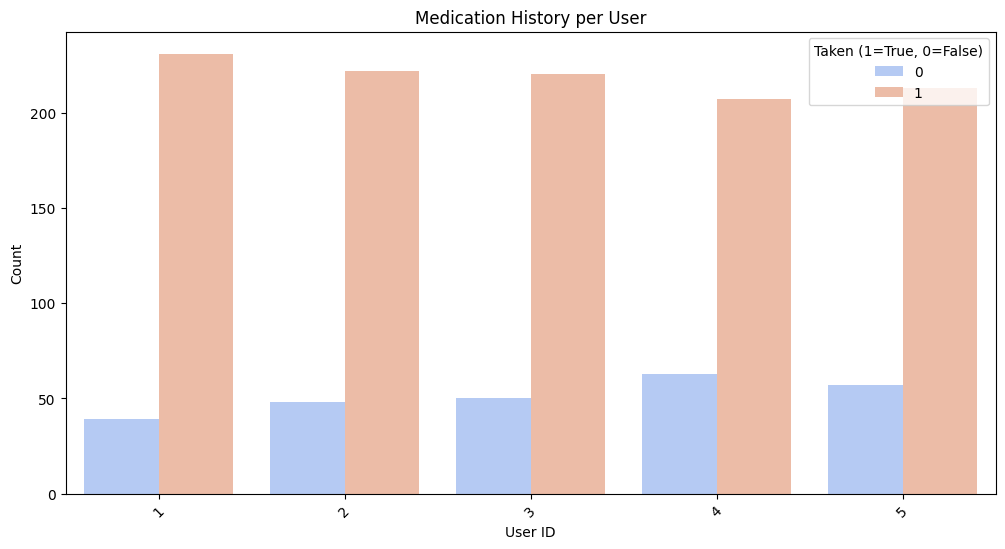

In [10]:
# Plot medication history per user
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='user_id', hue='taken', palette='coolwarm')
plt.title('Medication History per User')
plt.xlabel('User ID')
plt.ylabel('Count')
plt.legend(title='Taken (1=True, 0=False)')
plt.xticks(rotation=45)
plt.show()

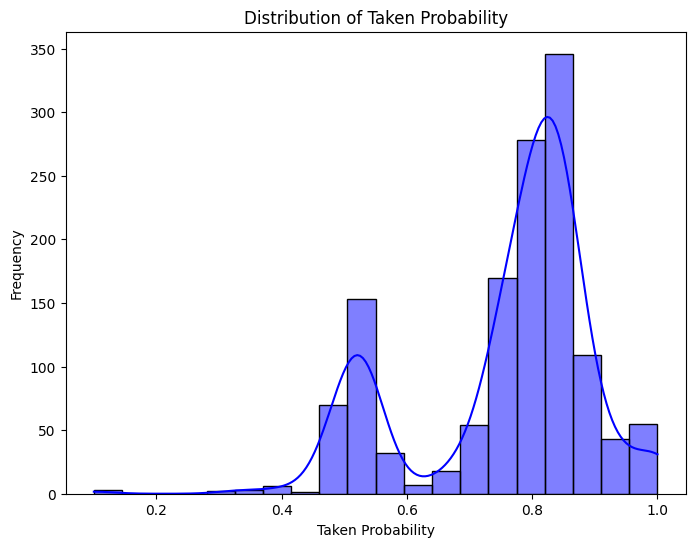

In [11]:
# 📊 1. Distribution of Taken_Probability
plt.figure(figsize=(8,6))
sns.histplot(df["prob"], bins=20, kde=True, color="blue")
plt.xlabel("Taken Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Taken Probability")
plt.show()

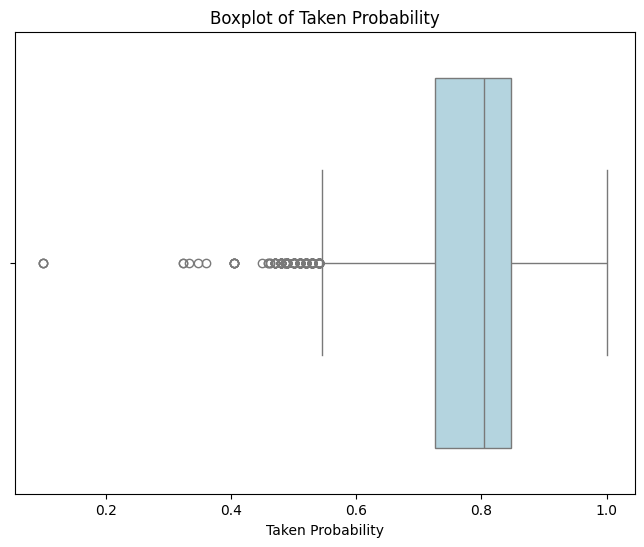

In [13]:
# 📊 2. Boxplot to check spread and outliers
plt.figure(figsize=(8,6))
sns.boxplot(x=df["prob"], color="lightblue")
plt.xlabel("Taken Probability")
plt.title("Boxplot of Taken Probability")
plt.show()

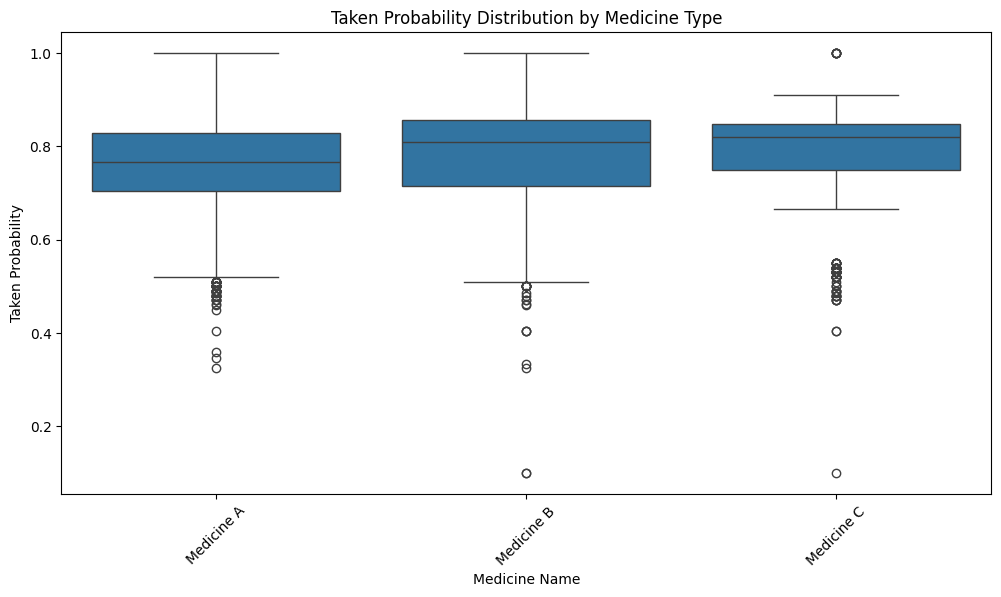

In [15]:
# 📊 3. Probability vs Medicine Type (if medicine names exist)
plt.figure(figsize=(12,6))
sns.boxplot(x=df["medicine_name"], y=df["prob"])
plt.xticks(rotation=45)
plt.xlabel("Medicine Name")
plt.ylabel("Taken Probability")
plt.title("Taken Probability Distribution by Medicine Type")
plt.show()

<ipython-input-17-0dec263543e0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['taken'], palette='coolwarm')


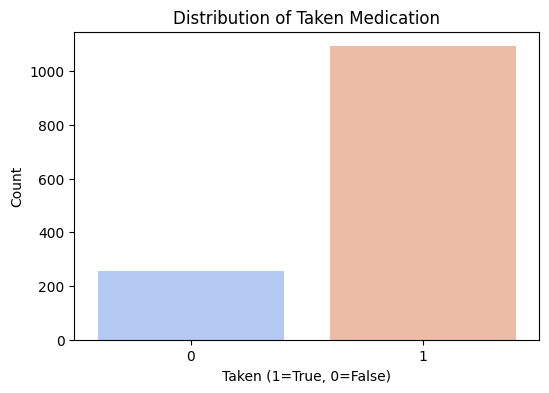

In [17]:
# Plot distribution of the taken column
plt.figure(figsize=(6, 4))
sns.countplot(x=df['taken'], palette='coolwarm')
plt.title('Distribution of Taken Medication')
plt.xlabel('Taken (1=True, 0=False)')
plt.ylabel('Count')
plt.show()

In [18]:
# Convert datetime column to pandas datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

In [19]:
# Display first few rows
display(df.head())

,user_id,datetime,medicine_name,taken,prob
0,1,2024-12-22 02:13:05.349555,Medicine A,1,1.00
1,1,2024-12-23 02:13:05.349555,Medicine A,1,1.00
2,1,2024-12-24 02:13:05.349555,Medicine A,0,0.47
3,1,2024-12-25 02:13:05.349555,Medicine A,1,0.75
4,1,2024-12-26 02:13:05.349555,Medicine A,1,0.80


In [20]:
# Assign real medicine names
medicine_mapping = {
    'Medicine A': 'Metformin',
    'Medicine B': 'Lisinopril',
    'Medicine C': 'Atorvastatin'
}
df['medicine_name'] = df['medicine_name'].map(medicine_mapping)

In [21]:
# Display first few rows
display(df.head(20))

,user_id,datetime,medicine_name,taken,prob
0,1,2024-12-22 02:13:05.349555,Metformin,1,1.000000
1,1,2024-12-23 02:13:05.349555,Metformin,1,1.000000
2,1,2024-12-24 02:13:05.349555,Metformin,0,0.470000
3,1,2024-12-25 02:13:05.349555,Metformin,1,0.750000
4,1,2024-12-26 02:13:05.349555,Metformin,1,0.800000
5,1,2024-12-27 02:13:05.349555,Metformin,1,0.833333
6,1,2024-12-28 02:13:05.349555,Metformin,0,0.490000
7,1,2024-12-29 02:13:05.349555,Metformin,0,0.450000
8,1,2024-12-30 02:13:05.349555,Metformin,1,0.666667
9,1,2024-12-31 02:13:05.349555,Metformin,0,0.486000


In [22]:
# Step 4: Data Exploration & Visualization
print("Dataset Statistics:\n", df.describe())
print("\nNumber of unique users:", df['user_id'].nunique())
print("\nNumber of unique medicines:", df['medicine_name'].nunique())
print("\nDataset Shape:", df.shape)

Dataset Statistics:
            user_id                       datetime        taken         prob
count  1350.000000                           1350  1350.000000  1350.000000
mean      3.000000  2025-02-04 20:13:05.349554432     0.809630     0.759265
min       1.000000     2024-12-22 02:13:05.349555     0.000000     0.100000
25%       2.000000  2025-01-13 08:13:05.349554944     1.000000     0.725568
50%       3.000000  2025-02-04 20:13:05.349554944     1.000000     0.804348
75%       4.000000  2025-02-27 08:13:05.349554944     1.000000     0.847059
max       5.000000     2025-03-21 14:13:05.349555     1.000000     1.000000
std       1.414738                            NaN     0.392739     0.141878

Number of unique users: 5

Number of unique medicines: 3

Dataset Shape: (1350, 5)


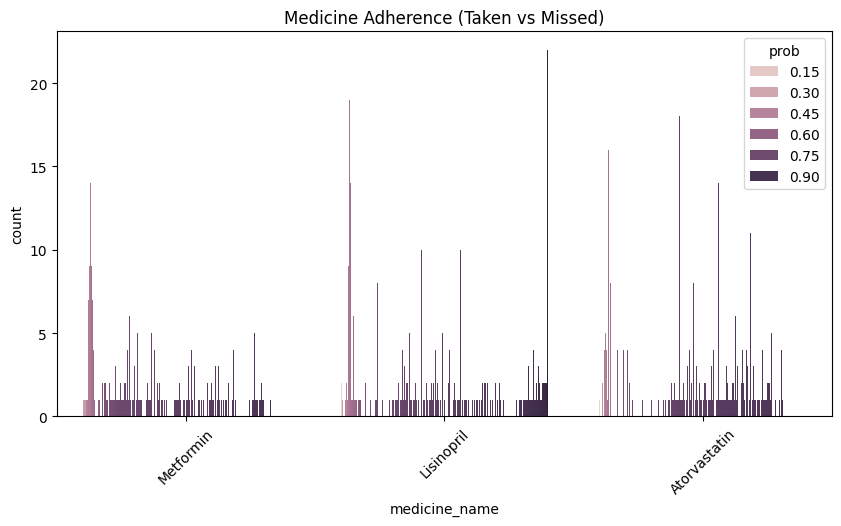

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='medicine_name', hue='prob')
plt.title("Medicine Adherence (Taken vs Missed)")
plt.xticks(rotation=45)
plt.show()

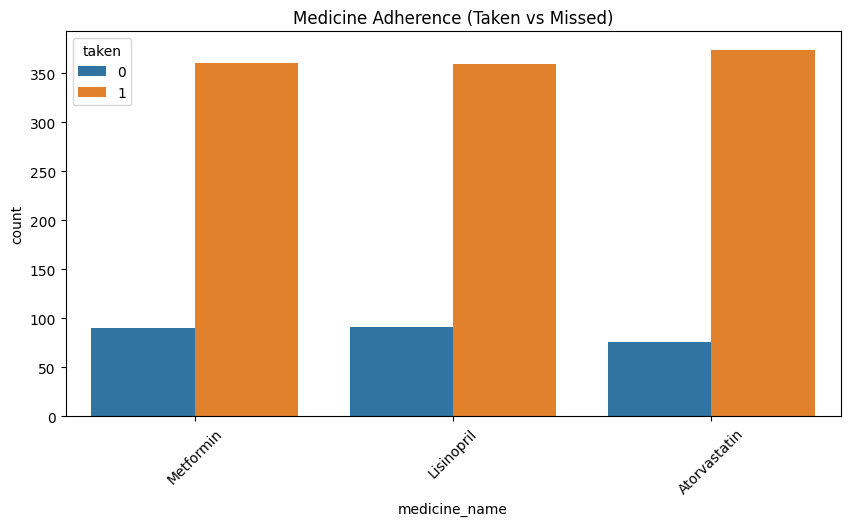

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='medicine_name', hue='taken')
plt.title("Medicine Adherence (Taken vs Missed)")
plt.xticks(rotation=45)
plt.show()

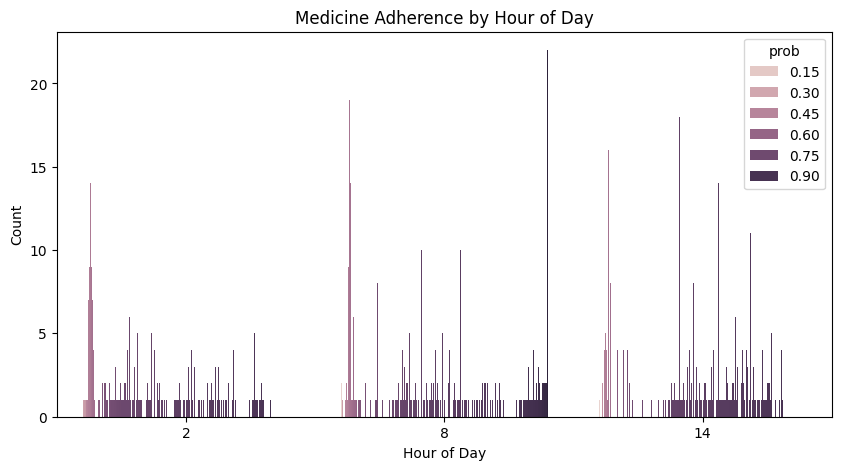

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['datetime'].dt.hour, hue=df['prob'])
plt.title("Medicine Adherence by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()

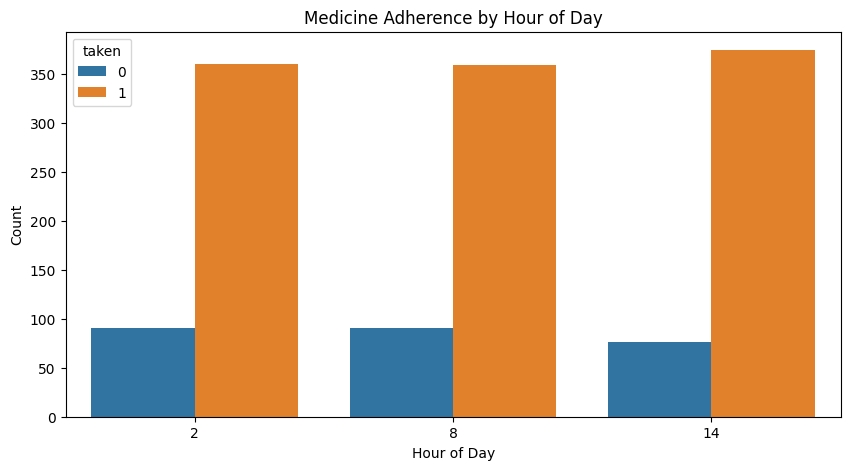

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['datetime'].dt.hour, hue=df['taken'])
plt.title("Medicine Adherence by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()


Statistics for User 1:
       user_id                       datetime       taken        prob
count    270.0                            270  270.000000  270.000000
mean       1.0  2025-02-04 20:13:05.349554688    0.855556    0.775416
min        1.0     2024-12-22 02:13:05.349555    0.000000    0.405000
25%        1.0  2025-01-13 09:43:05.349554944    1.000000    0.771753
50%        1.0  2025-02-04 20:13:05.349554944    1.000000    0.814120
75%        1.0  2025-02-27 06:43:05.349554944    1.000000    0.845883
max        1.0     2025-03-21 14:13:05.349555    1.000000    1.000000
std        0.0                            NaN    0.352193    0.120983


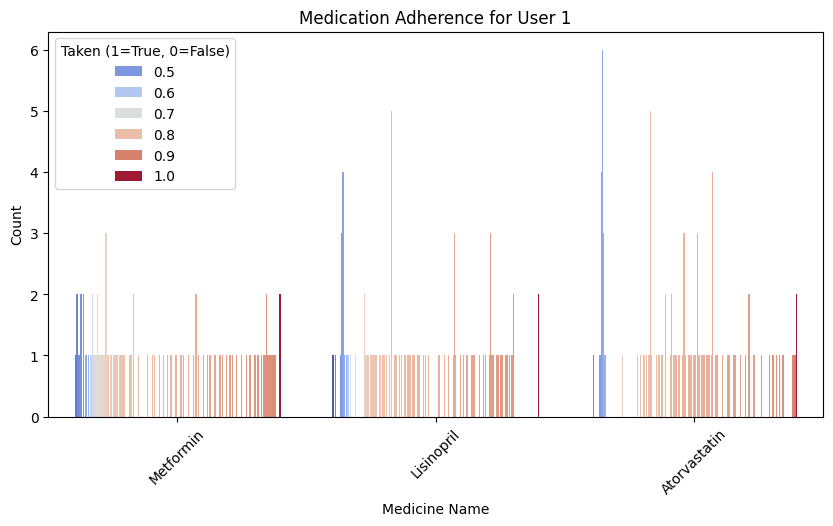

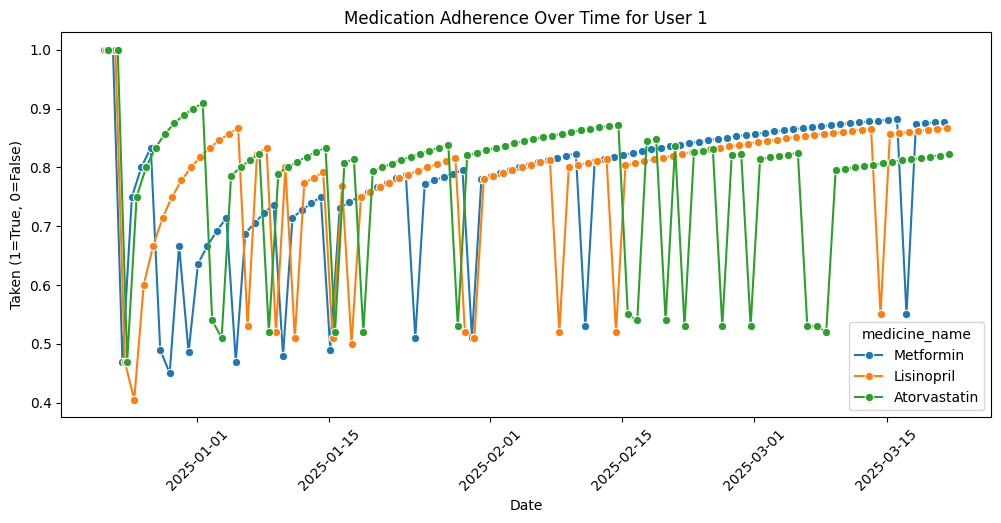

--------------------------------------------------

Statistics for User 2:
       user_id                       datetime       taken        prob
count    270.0                            270  270.000000  270.000000
mean       2.0  2025-02-04 20:13:05.349554688    0.822222    0.787748
min        2.0     2024-12-22 02:13:05.349555    0.000000    0.405000
25%        2.0  2025-01-13 09:43:05.349554944    1.000000    0.750000
50%        2.0  2025-02-04 20:13:05.349554944    1.000000    0.821162
75%        2.0  2025-02-27 06:43:05.349554944    1.000000    0.855215
max        2.0     2025-03-21 14:13:05.349555    1.000000    1.000000
std        0.0                            NaN    0.383036    0.142708


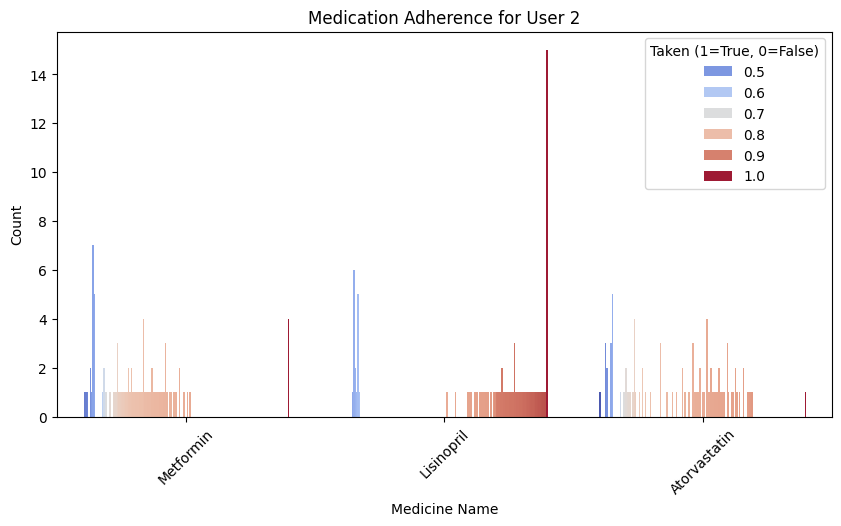

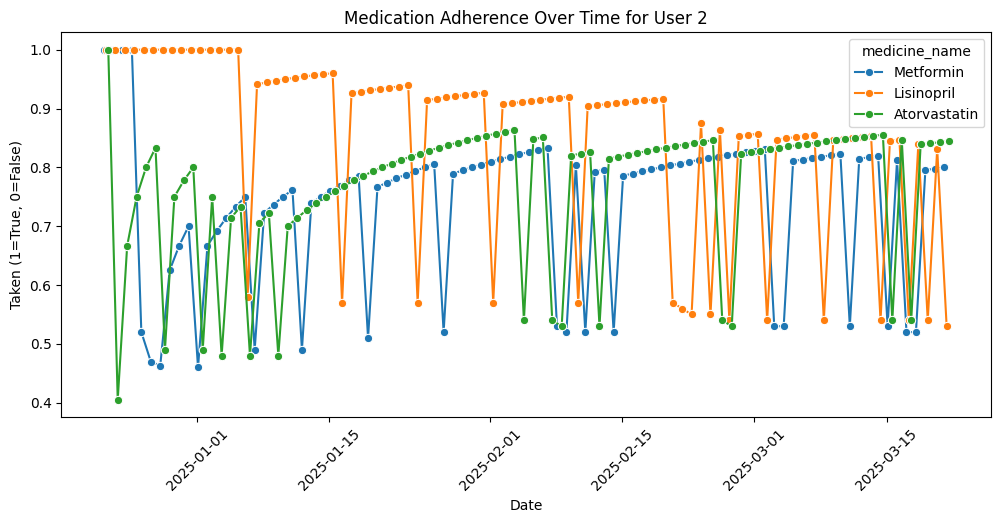

--------------------------------------------------

Statistics for User 3:
       user_id                       datetime       taken        prob
count    270.0                            270  270.000000  270.000000
mean       3.0  2025-02-04 20:13:05.349554688    0.814815    0.761439
min        3.0     2024-12-22 02:13:05.349555    0.000000    0.100000
25%        3.0  2025-01-13 09:43:05.349554944    1.000000    0.709821
50%        3.0  2025-02-04 20:13:05.349554944    1.000000    0.826837
75%        3.0  2025-02-27 06:43:05.349554944    1.000000    0.852042
max        3.0     2025-03-21 14:13:05.349555    1.000000    1.000000
std        0.0                            NaN    0.389169    0.152774


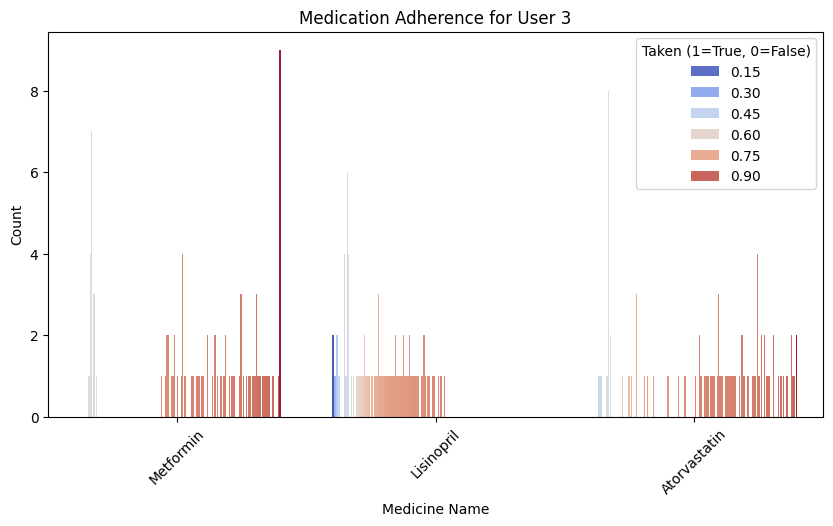

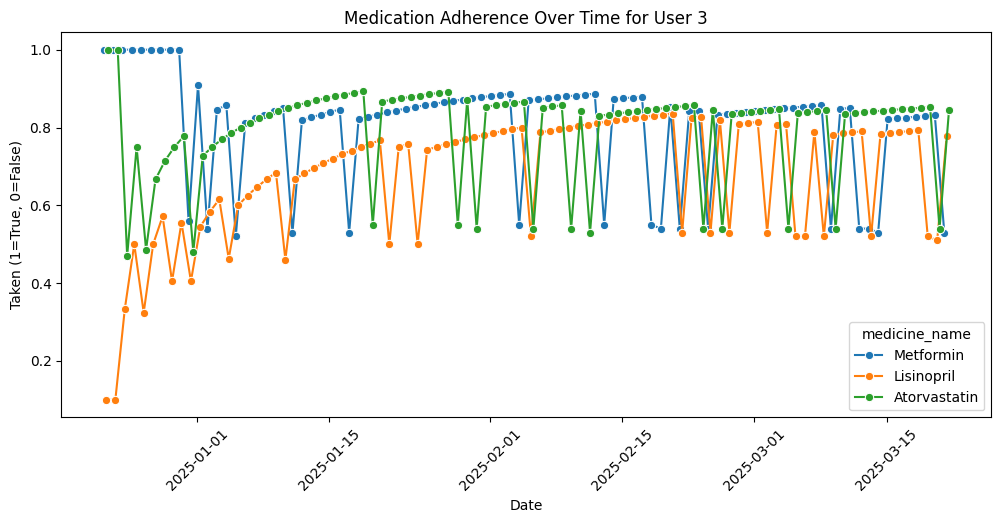

--------------------------------------------------

Statistics for User 4:
       user_id                       datetime       taken        prob
count    270.0                            270  270.000000  270.000000
mean       4.0  2025-02-04 20:13:05.349554688    0.766667    0.726354
min        4.0     2024-12-22 02:13:05.349555    0.000000    0.100000
25%        4.0  2025-01-13 09:43:05.349554944    1.000000    0.573333
50%        4.0  2025-02-04 20:13:05.349554944    1.000000    0.765165
75%        4.0  2025-02-27 06:43:05.349554944    1.000000    0.812274
max        4.0     2025-03-21 14:13:05.349555    1.000000    1.000000
std        0.0                            NaN    0.423738    0.150310


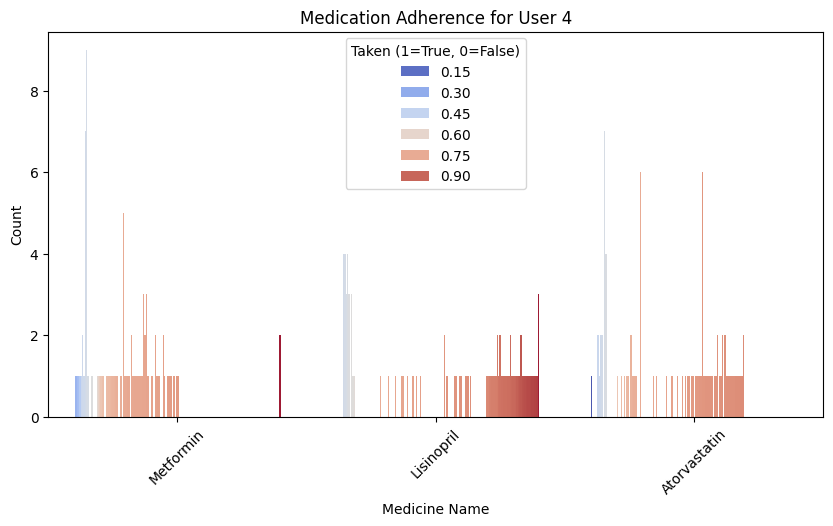

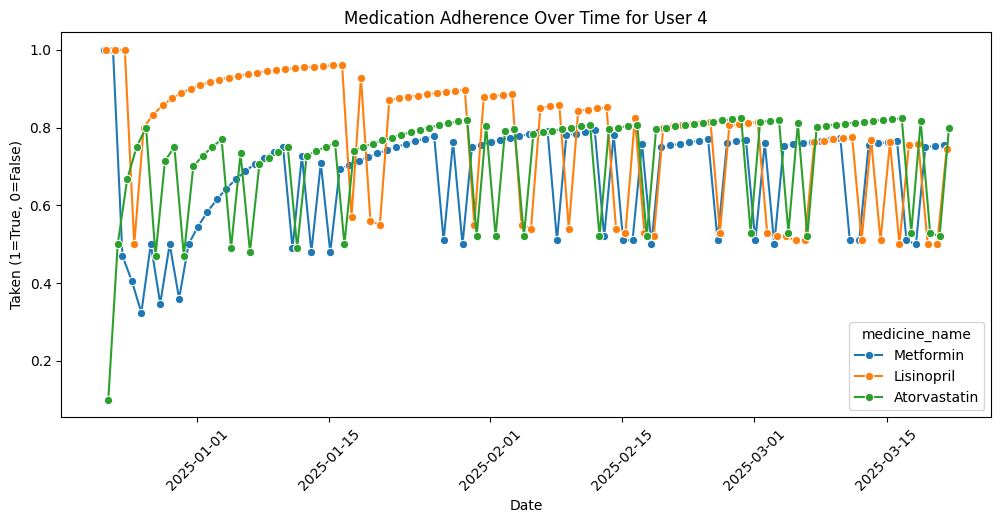

--------------------------------------------------

Statistics for User 5:
       user_id                       datetime       taken        prob
count    270.0                            270  270.000000  270.000000
mean       5.0  2025-02-04 20:13:05.349554688    0.788889    0.745369
min        5.0     2024-12-22 02:13:05.349555    0.000000    0.405000
25%        5.0  2025-01-13 09:43:05.349554944    1.000000    0.718149
50%        5.0  2025-02-04 20:13:05.349554944    1.000000    0.778424
75%        5.0  2025-02-27 06:43:05.349554944    1.000000    0.841579
max        5.0     2025-03-21 14:13:05.349555    1.000000    1.000000
std        0.0                            NaN    0.408855    0.132850


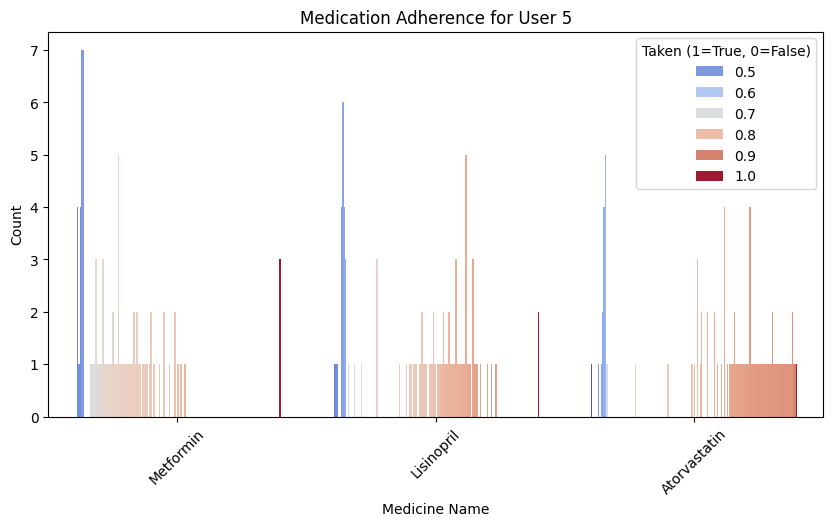

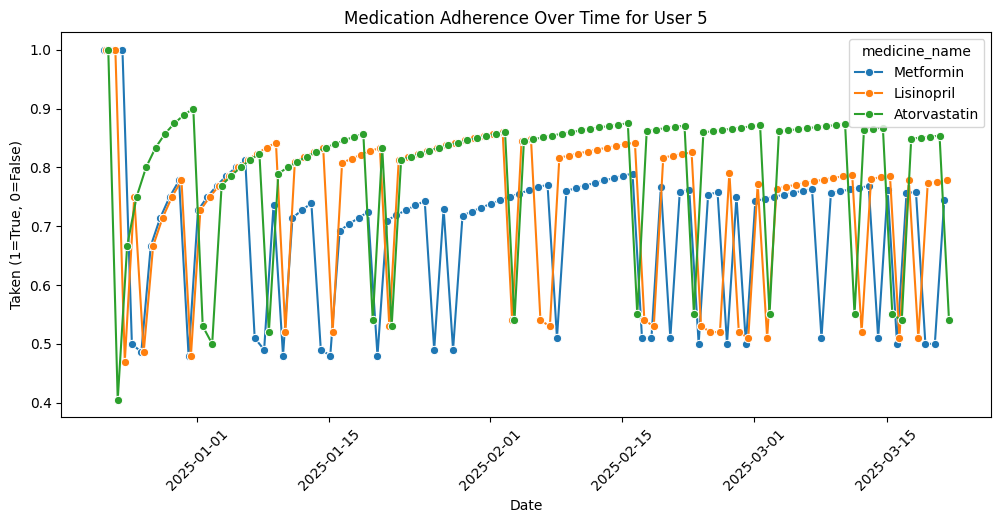

--------------------------------------------------


In [28]:
# Step 6: Generate statistics and graphs for each user
for user in df['user_id'].unique():
    user_df = df[df['user_id'] == user]

    print(f"\nStatistics for User {user}:")
    print(user_df.describe())

    # Countplot of medicine taken history
    plt.figure(figsize=(10, 5))
    sns.countplot(data=user_df, x='medicine_name', hue='prob', palette='coolwarm')
    plt.title(f'Medication Adherence for User {user}')
    plt.xlabel('Medicine Name')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Taken (1=True, 0=False)')
    plt.show()

    # Time-series plot of medicine adherence
    user_df = user_df.sort_values(by='datetime')
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=user_df, x='datetime', y='prob', hue='medicine_name', marker='o')
    plt.title(f'Medication Adherence Over Time for User {user}')
    plt.xlabel('Date')
    plt.ylabel('Taken (1=True, 0=False)')
    plt.xticks(rotation=45)
    plt.show()

    print("-" * 50)


In [29]:
# Step 5: Feature Engineering
df['timestamp'] = df['datetime'].astype(int) // 10**9  # Convert datetime to UNIX timestamp
df['day_of_week'] = df['datetime'].dt.dayofweek  # Extract day of the week
df['hour_of_day'] = df['datetime'].dt.hour  # Extract hour of the day

In [30]:
# Encode user IDs and medicine names
user_encoder = LabelEncoder()
df['user_id'] = user_encoder.fit_transform(df['user_id'])

medicine_encoder = LabelEncoder()
df['medicine_name'] = medicine_encoder.fit_transform(df['medicine_name'])

In [31]:
df.head(10)

,user_id,datetime,medicine_name,taken,prob,timestamp,day_of_week,hour_of_day
0,0,2024-12-22 02:13:05.349555,2,1,1.000000,1734833585,6,2
1,0,2024-12-23 02:13:05.349555,2,1,1.000000,1734919985,0,2
2,0,2024-12-24 02:13:05.349555,2,0,0.470000,1735006385,1,2
3,0,2024-12-25 02:13:05.349555,2,1,0.750000,1735092785,2,2
4,0,2024-12-26 02:13:05.349555,2,1,0.800000,1735179185,3,2
5,0,2024-12-27 02:13:05.349555,2,1,0.833333,1735265585,4,2
6,0,2024-12-28 02:13:05.349555,2,0,0.490000,1735351985,5,2
7,0,2024-12-29 02:13:05.349555,2,0,0.450000,1735438385,6,2
8,0,2024-12-30 02:13:05.349555,2,1,0.666667,1735524785,0,2
9,0,2024-12-31 02:13:05.349555,2,0,0.486000,1735611185,1,2


In [48]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Initialize encoders & scalers
scaler = MinMaxScaler()
med_encoder = LabelEncoder()
user_encoder = LabelEncoder()

# Encode categorical features
df['medicine_name'] = med_encoder.fit_transform(df['medicine_name'])
df['user_id'] = user_encoder.fit_transform(df['user_id'])

# Normalize timestamp
df['timestamp'] = scaler.fit_transform(df[['timestamp']])

sequence_length = 14  # Use last 14 records to predict the next probability
X, y = [], []

for user in df['user_id'].unique():
    user_df = df[df['user_id'] == user]
    for med in user_df['medicine_name'].unique():
        med_df = user_df[user_df['medicine_name'] == med].sort_values('datetime')

        # Select features (all except the target)
        data = med_df[['timestamp', 'day_of_week', 'hour_of_day', 'user_id', 'medicine_name']].values
        labels = med_df['prob'].values  # New target

        for i in range(len(data) - sequence_length):
            X.append(data[i:i + sequence_length])
            y.append(labels[i + sequence_length])  # Predict the probability

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y).reshape(-1, 1)


In [49]:
X.shape, y.shape

((1140, 14, 5), (1140, 1))

In [50]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)


X_train Shape: (912, 14, 5)
y_train Shape: (912, 1)
X_test Shape: (228, 14, 5)
y_test Shape: (228, 1)


In [ ]:
import pickle

# Save encoders and scaler
with open('./Preloads/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('./Preloads/med_encoder.pkl', 'wb') as f:
    pickle.dump(med_encoder, f)

with open('./Preloads/user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)


In [56]:
# Step 7: Build LSTM Model for Regression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Build LSTM Model
model = Sequential([
    Bidirectional(LSTM(512, activation='tanh', return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(256, activation='tanh', return_sequences=True)),
    BatchNormalization(),
    Dropout(0.4),

    Bidirectional(LSTM(128, activation='tanh', return_sequences=True)),
    BatchNormalization(),
    Dropout(0.4),

    TimeDistributed(Dense(16, activation='relu')),
    Dense(1)  # Output a single continuous probability value
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss=tf.keras.losses.Huber(), metrics=['mae'])


# Model Summary
print("\nModel Summary:")
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_12 (Bidirectional)     │ (None, 14, 1024)            │       2,121,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 14, 1024)            │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 14, 1024)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_13 (Bidirectional)     │ (None, 14, 512)             │       2,623,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 14, 512)             │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 14, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_14 (Bidirectional)     │ (None, 14, 256)             │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 14, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 14, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 14, 16)              │           4,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 14, 1)               │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,412,897 (20.65 MB)

 Trainable params: 5,409,313 (20.63 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
# Callbacks
checkpoint = ModelCheckpoint("./Preloads/final_model1.keras", monitor="val_loss", save_best_only=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [58]:
# Train Model
print("\nTraining Model...")
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_data=(X_test, y_test), verbose=1, callbacks=[checkpoint, early_stopping])



Training Model...
Epoch 1/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - loss: 0.8473 - mae: 1.2537 - val_loss: 0.3699 - val_mae: 0.8393
Epoch 2/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1000ms/step - loss: 0.5062 - mae: 0.8786 - val_loss: 0.3922 - val_mae: 0.8565
Epoch 3/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.4196 - mae: 0.7781 - val_loss: 0.3309 - val_mae: 0.7946
Epoch 4/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 997ms/step - loss: 0.3532 - mae: 0.6978 - val_loss: 0.3699 - val_mae: 0.8336
Epoch 5/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.2970 - mae: 0.6318 - val_loss: 0.2486 - val_mae: 0.6695
Epoch 6/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.2591 - mae: 0.5878 - val_loss: 0.2290 - val_mae: 0.6467
Epoch 7/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.2254 - mae: 0.5417 - val_loss: 0.2039 - val_mae: 0.6098
Epoch 8/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.1900 - mae: 0.4962 - val_loss: 0.1376 - val_mae: 0.4980
Epoch 9/150
29/29 ━━━━━━━━━━━━━━━━━━━━

In [96]:
# Get model predictions
y_pred = model.predict(X_test)

# Check original shapes
print(f"y_pred shape before: {y_pred.shape}")  # (228, 14, 1)
print(f"y_test shape before: {y_test.shape}")  # (228, 1)

# Reshape y_pred to match y_test
y_pred = y_pred[:, -1, 0].reshape(-1, 1)  # Take last timestep prediction

# Check new shape
print(f"y_pred shape after: {y_pred.shape}")  # Should be (228, 1)

# Compute performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error


# Display results
print("\n📌 **Model Performance Metrics:**")
print(f"✅ Mean Absolute Error (MAE): {mae:.4f}")
print(f"✅ Mean Squared Error (MSE): {mse:.4f}")
print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f}")



8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 389ms/step
y_pred shape before: (228, 14, 1)
y_test shape before: (228, 1)
y_pred shape after: (228, 1)

📌 **Model Performance Metrics:**
✅ Mean Absolute Error (MAE): 0.1207
✅ Mean Squared Error (MSE): 0.0162
✅ Root Mean Squared Error (RMSE): 0.1272


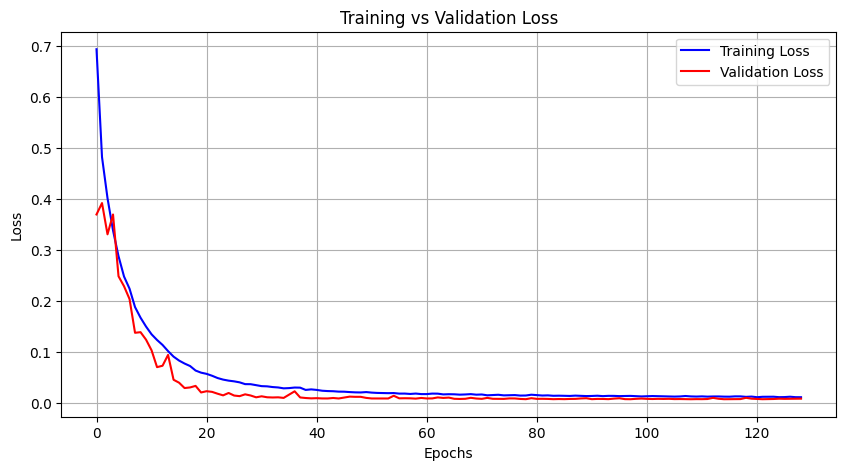

In [60]:
# 📌 1. Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

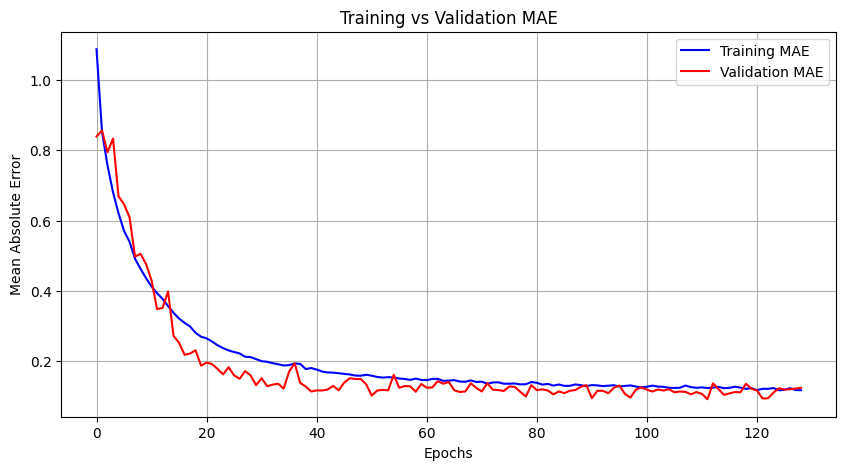

In [61]:
# 📌 2. Plot Training & Validation MAE
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE', color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', color='red')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#model.save("./Preloads/model.keras")